In [4]:
import os
os.listdir("data")

['house_price_data.csv']

In [5]:
import pandas as pd

df = pd.read_csv("data/house_price_data.csv")
df.shape

(177528, 13)

In [6]:
df.head()

,BHK,Amount(in rupees),Location,Floor,Transaction,Furnishing,Bathroom,Balcony,Covered Parking,Open Parking,Garden/Park,Main Road,Pool
0,1,4200000,thane,10,Resale,Unfurnished,1,2,0,0,0,0,0
1,2,9800000,thane,3,Resale,Semi-Furnished,2,0,0,1,1,0,0
2,2,14000000,thane,10,Resale,Unfurnished,2,0,1,0,1,0,0
3,1,2500000,thane,1,Resale,Unfurnished,1,1,0,0,0,0,0
4,2,16000000,thane,20,Resale,Unfurnished,2,0,1,0,1,1,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177528 entries, 0 to 177527
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   BHK                177528 non-null  int64
 1   Amount(in rupees)  177528 non-null  int64
 2   Location           177528 non-null  str  
 3   Floor              177528 non-null  int64
 4   Transaction        177528 non-null  str  
 5   Furnishing         177528 non-null  str  
 6   Bathroom           177528 non-null  str  
 7   Balcony            177528 non-null  str  
 8   Covered Parking    177528 non-null  int64
 9   Open Parking       177528 non-null  int64
 10  Garden/Park        177528 non-null  int64
 11  Main Road          177528 non-null  int64
 12  Pool               177528 non-null  int64
dtypes: int64(8), str(5)
memory usage: 17.6 MB


df.isna().mean().sort_values(ascending=False)

## 2.1 Load & Inspect
- عدد الصفوف: 177,528 وعدد الأعمدة: 13
- الأعمدة الرقمية: BHK, Amount(in rupees), Floor, Covered Parking, Open Parking, Garden/Park, Main Road, Pool
- الأعمدة النصية: Location, Transaction, Furnishing, Bathroom, Balcony
- لا توجد قيم ناقصة (missing values) في أي عمود

In [8]:
df["Bathroom"].unique()

<StringArray>
['1', '2', '3', '4', '6', '5', '0', '9', '8', '> 10', '7', '10']
Length: 12, dtype: str

In [9]:
df["Balcony"].unique()

<StringArray>
['2', '0', '1', '3', '4', '6', '5', '7', '> 10', '10', '8', '9']
Length: 12, dtype: str

In [10]:
def clean_number(x):
    x = str(x).strip()
    if x == "> 10":
        return 11
    return float(x)

df["Bathroom"] = df["Bathroom"].apply(clean_number)
df["Balcony"] = df["Balcony"].apply(clean_number)

In [11]:
df["Bathroom"].unique()
df["Balcony"].unique()

array([ 2.,  0.,  1.,  3.,  4.,  6.,  5.,  7., 11., 10.,  8.,  9.])

In [12]:
df["Balcony"].unique()

array([ 2.,  0.,  1.,  3.,  4.,  6.,  5.,  7., 11., 10.,  8.,  9.])

In [13]:
df["Bathroom"].unique()

array([ 1.,  2.,  3.,  4.,  6.,  5.,  0.,  9.,  8., 11.,  7., 10.])

In [14]:
print(df["Transaction"].unique())
print(df["Furnishing"].unique())
print(df["Location"].nunique())

<StringArray>
['Resale', 'New Property', '0', 'Other', 'Rent/Lease']
Length: 5, dtype: str
<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished', '0']
Length: 4, dtype: str
81


In [15]:
# نستبدل "0" بقيمة واضحة معناها "غير معروف"
df["Transaction"] = df["Transaction"].replace("0", "Unknown")
df["Furnishing"] = df["Furnishing"].replace("0", "Unknown")

In [16]:
print(df["Transaction"].unique())
print(df["Furnishing"].unique())

<StringArray>
['Resale', 'New Property', 'Unknown', 'Other', 'Rent/Lease']
Length: 5, dtype: str
<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished', 'Unknown']
Length: 4, dtype: str


In [17]:
df["Amount(in rupees)"].describe()

count    1.775280e+05
mean     1.198953e+07
std      3.942497e+07
min      1.000000e+05
25%      4.900000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Amount(in rupees), dtype: float64

In [18]:
# نحسب الحد الأدنى والأقصى المقبول (1% و99%)
lower = df["Amount(in rupees)"].quantile(0.01)
upper = df["Amount(in rupees)"].quantile(0.99)

print("Lower bound:", lower)
print("Upper bound:", upper)

# نشيل أي صف السعر بتاعه برا الحدود دي
df = df[(df["Amount(in rupees)"] >= lower) & (df["Amount(in rupees)"] <= upper)]

df.shape

Lower bound: 1600000.0
Upper bound: 70000000.0


(175248, 13)

In [19]:
print(df.columns)

Index(['BHK', 'Amount(in rupees)', 'Location', 'Floor', 'Transaction',
       'Furnishing', 'Bathroom', 'Balcony', 'Covered Parking', 'Open Parking',
       'Garden/Park', 'Main Road', 'Pool'],
      dtype='str')


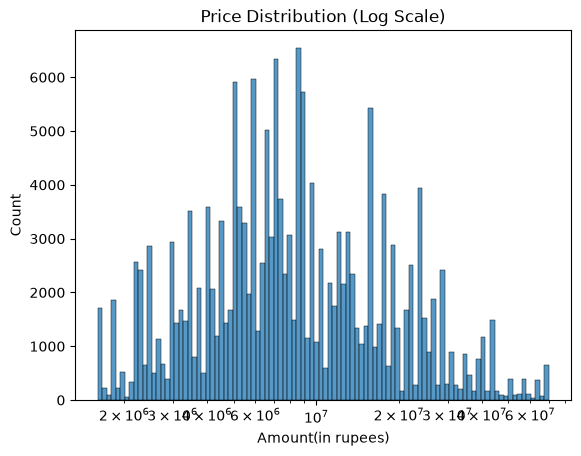

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Amount(in rupees)"], log_scale=True)
plt.title("Price Distribution (Log Scale)")
plt.show()

2.1 Load & Inspect

In [21]:
import pandas as pd
df = pd.read_csv("data/house_price_data.csv")
df.shape 
df.head()
df.info()
df.describe()
# how many rows/columns?
# dtypes, missing values
df.isna().mean().sort_values(ascending=False) # % missing per column

<class 'pandas.DataFrame'>
RangeIndex: 177528 entries, 0 to 177527
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   BHK                177528 non-null  int64
 1   Amount(in rupees)  177528 non-null  int64
 2   Location           177528 non-null  str  
 3   Floor              177528 non-null  int64
 4   Transaction        177528 non-null  str  
 5   Furnishing         177528 non-null  str  
 6   Bathroom           177528 non-null  str  
 7   Balcony            177528 non-null  str  
 8   Covered Parking    177528 non-null  int64
 9   Open Parking       177528 non-null  int64
 10  Garden/Park        177528 non-null  int64
 11  Main Road          177528 non-null  int64
 12  Pool               177528 non-null  int64
dtypes: int64(8), str(5)
memory usage: 17.6 MB


BHK                  0.0
Amount(in rupees)    0.0
Location             0.0
Floor                0.0
Transaction          0.0
Furnishing           0.0
Bathroom             0.0
Balcony              0.0
Covered Parking      0.0
Open Parking         0.0
Garden/Park          0.0
Main Road            0.0
Pool                 0.0
dtype: float64

2.2 Exploratory Data Analysis (EDA)

1.Distribution of the target price (it will be heavily skewed — try a log scale).

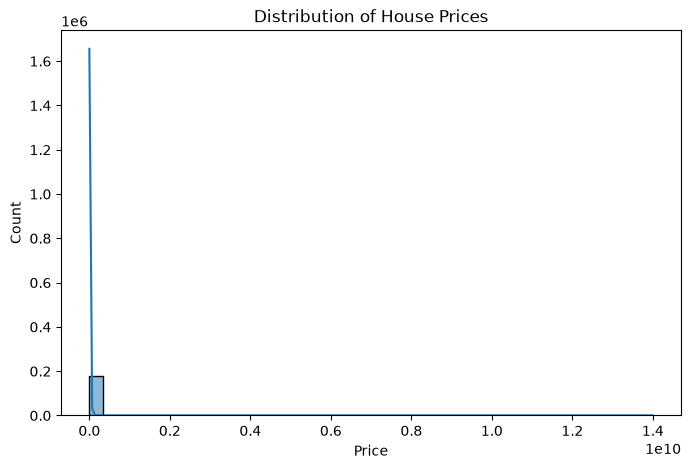

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(df["Amount(in rupees)"], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

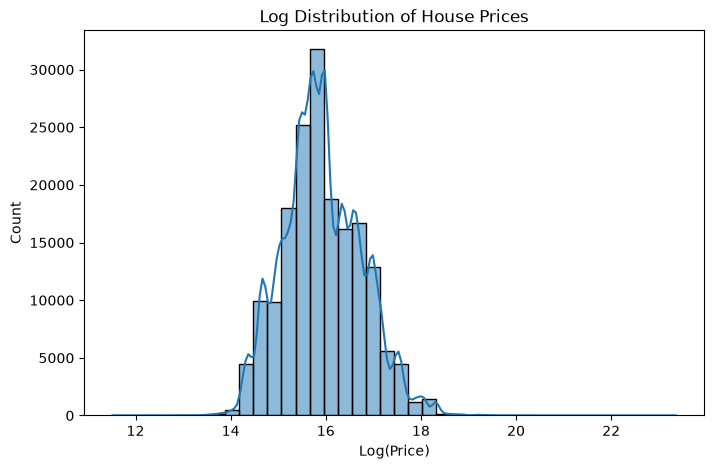

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df["Amount(in rupees)"]),
    bins=40,
    kde=True
)

plt.title("Log Distribution of House Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Count")

plt.show()

The house prices are highly right-skewed, indicating the presence of expensive properties. After applying the logarithmic transformation, the distribution becomes more symmetric, making it more suitable for machine learning models

2) Price vs Carpet Area

In [24]:
for col in df.columns:
    print(col)

BHK
Amount(in rupees)
Location
Floor
Transaction
Furnishing
Bathroom
Balcony
Covered Parking
Open Parking
Garden/Park
Main Road
Pool


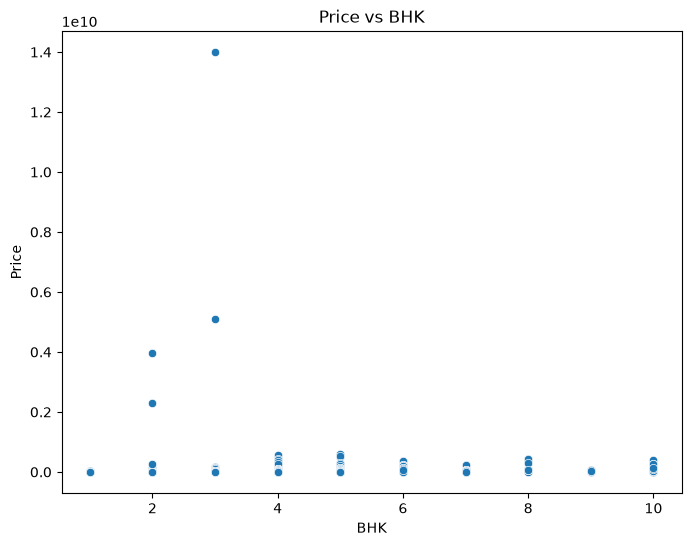

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["BHK"],
    y=df["Amount(in rupees)"]
)

plt.title("Price vs BHK")
plt.xlabel("BHK")
plt.ylabel("Price")

plt.show()

There is a positive relationship between the number of BHK and the house price. Properties with more bedrooms generally have higher prices, although there are some outliers.

In [26]:
print(df["Location"].nunique())

81


In [27]:
print(df.shape)

(177528, 13)


In [28]:
print(df["Location"].nunique())

81


3) Average Price by Top 15 Locations

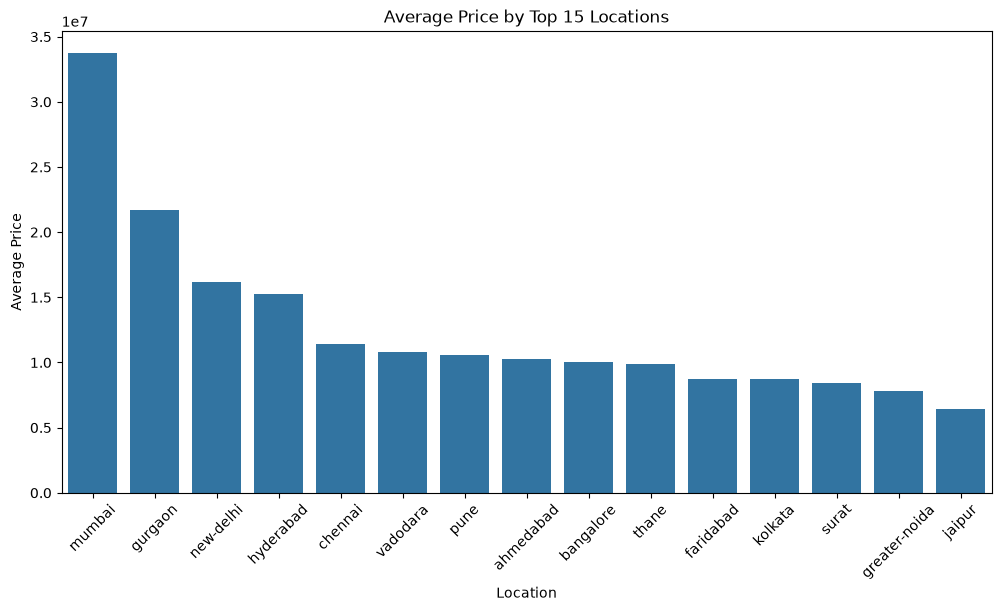

In [29]:
top15 = df["Location"].value_counts().head(15).index

avg_price = (
    df[df["Location"].isin(top15)]
      .groupby("Location")["Amount(in rupees)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.index, y=avg_price.values)

plt.xticks(rotation=45)
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price")

plt.show()

4) Price by Furnishing Status (Box Plot)

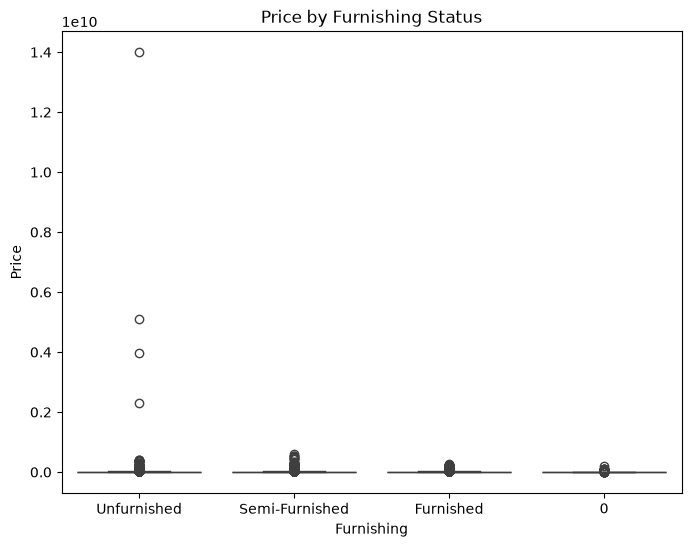

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["Furnishing"],
    y=df["Amount(in rupees)"]
)

plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price")

plt.show()

5) Price by Number of Bathrooms (Box Plot)

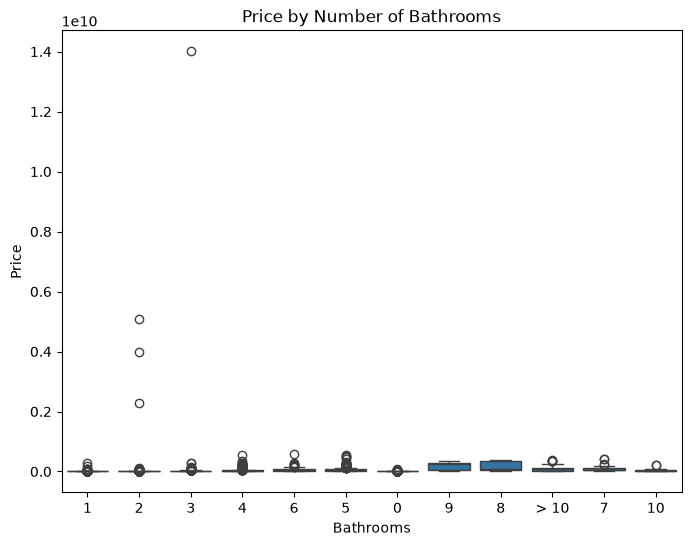

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["Bathroom"],
    y=df["Amount(in rupees)"]
)

plt.title("Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")

plt.show()

In [32]:
df["Amount(in rupees)"].head(10)

0     4200000
1     9800000
2    14000000
3     2500000
4    16000000
5     4500000
6     1650000
7     6000000
8     6000000
9    16000000
Name: Amount(in rupees), dtype: int64

In [33]:
df["Amount(in rupees)"].dtype

dtype('int64')

In [34]:
df["Floor"].unique()[:20]

array([10,  3,  1, 20,  2,  4,  0,  6, 16,  8, 18,  5, 15, 27, 11,  9, 14,
       12,  7, 21])

In [35]:
top50 = df["Location"].value_counts().head(50).index

df["Location"] = df["Location"].apply(
    lambda x: x if x in top50 else "Other"
)

In [36]:
df.dropna(axis=1, thresh=len(df)*0.3, inplace=True)

In [37]:
Q1 = df["Amount(in rupees)"].quantile(0.01)
Q99 = df["Amount(in rupees)"].quantile(0.99)

df = df[
    (df["Amount(in rupees)"] >= Q1) &
    (df["Amount(in rupees)"] <= Q99)
]

In [38]:
print(df.dtypes)

BHK                  int64
Amount(in rupees)    int64
Location               str
Floor                int64
Transaction            str
Furnishing             str
Bathroom               str
Balcony                str
Covered Parking      int64
Open Parking         int64
Garden/Park          int64
Main Road            int64
Pool                 int64
dtype: object


In [39]:
print(df.isnull().sum())

BHK                  0
Amount(in rupees)    0
Location             0
Floor                0
Transaction          0
Furnishing           0
Bathroom             0
Balcony              0
Covered Parking      0
Open Parking         0
Garden/Park          0
Main Road            0
Pool                 0
dtype: int64


In [40]:
print(df["Amount(in rupees)"].describe())

count    1.752480e+05
mean     1.126990e+07
std      1.029845e+07
min      1.600000e+06
25%      4.950000e+06
50%      7.800000e+06
75%      1.440000e+07
max      7.000000e+07
Name: Amount(in rupees), dtype: float64


In [41]:
print(df["Location"].nunique())

51


In [42]:
print(df["Location"].value_counts().tail())

Location
panchkula    329
guntur       265
varanasi     257
nashik       238
thrissur     203
Name: count, dtype: int64


print(df["Floor"].head(20))

In [43]:
# نحسب الحد الأدنى والأقصى المقبول (1% و99%)
lower = df["Amount(in rupees)"].quantile(0.01)
upper = df["Amount(in rupees)"].quantile(0.99)

print("Lower bound:", lower)
print("Upper bound:", upper)

# نشيل أي صف السعر بتاعه برا الحدود دي
df = df[(df["Amount(in rupees)"] >= lower) & (df["Amount(in rupees)"] <= upper)]

df.shape

Lower bound: 1700000.0
Upper bound: 53000000.0


(171772, 13)

## 2.3 Cleaning & Feature Engineering
- حوّلنا Bathroom و Balcony من نص إلى رقم (القيمة "> 10" اعتُبرت 11)
- استبدلنا القيمة "0" في Transaction و Furnishing بـ "Unknown" لأنها كانت تمثل بيانات غير معروفة
- أزلنا القيم الشاذة في السعر (أقل من 1% وأعلى من 99%) لأن أعلى قيمة كانت غير منطقية (14 مليار روبية)
- بعد التنظيف: 171,772 صف

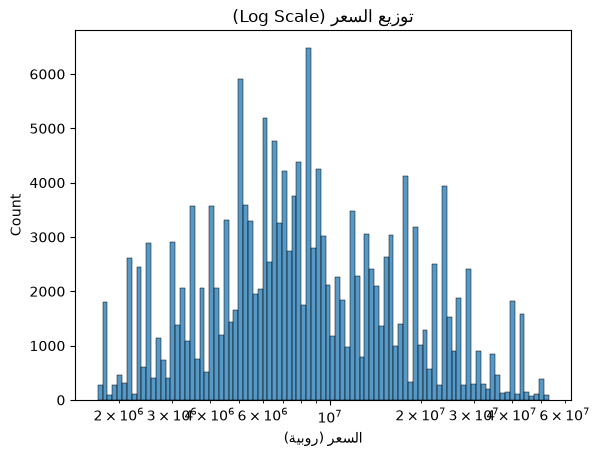

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Amount(in rupees)"], log_scale=True)
plt.title("توزيع السعر (Log Scale)")
plt.xlabel("السعر (روبية)")
plt.show()

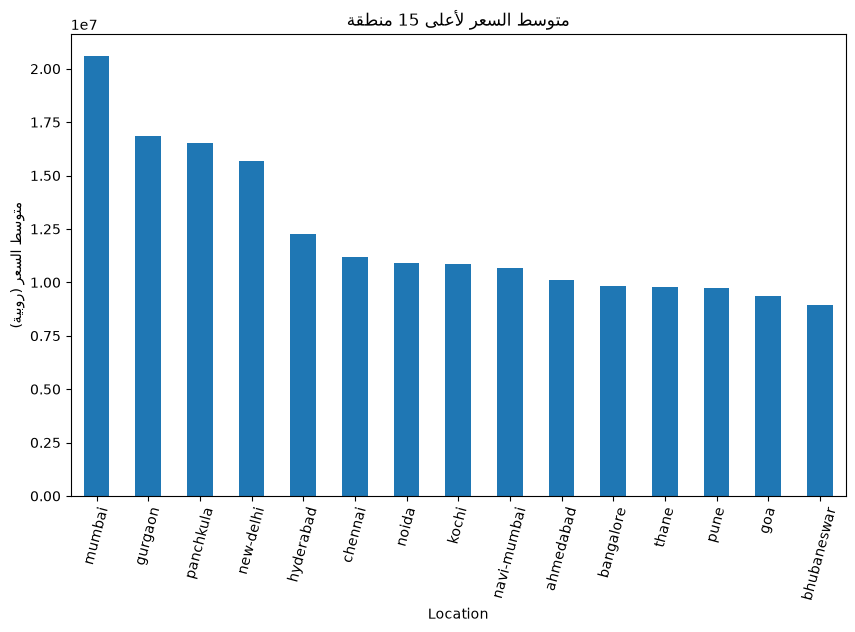

In [45]:
top_locations = df.groupby("Location")["Amount(in rupees)"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_locations.plot(kind="bar")
plt.title("متوسط السعر لأعلى 15 منطقة")
plt.ylabel("متوسط السعر (روبية)")
plt.xticks(rotation=75)
plt.show()

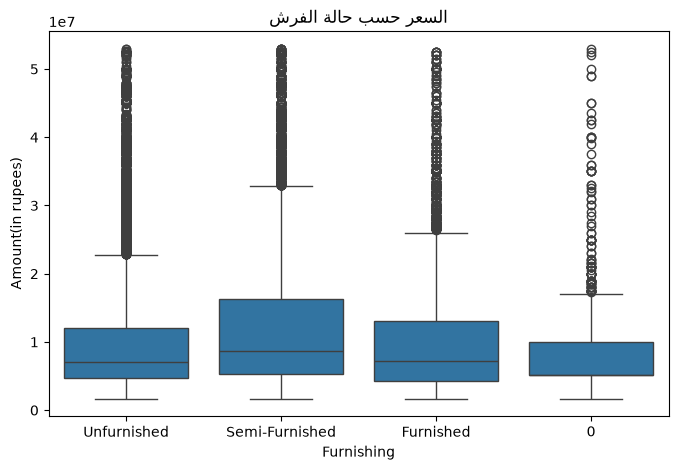

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Furnishing", y="Amount(in rupees)", data=df)
plt.title("السعر حسب حالة الفرش")
plt.show()

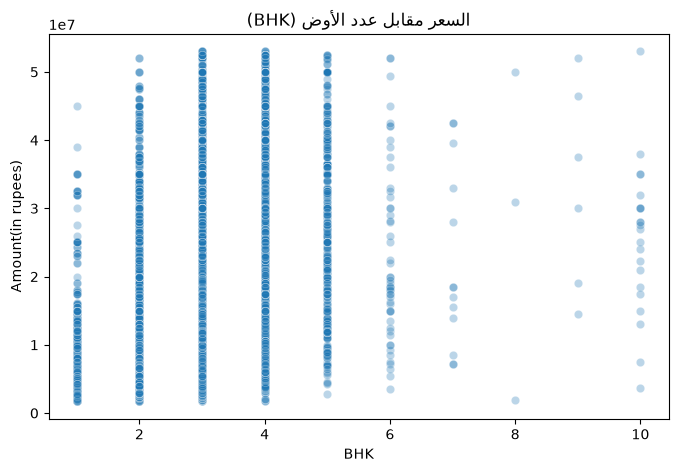

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="BHK", y="Amount(in rupees)", data=df, alpha=0.3)
plt.title("السعر مقابل عدد الأوض (BHK)")
plt.show()

## 2.2 EDA
- توزيع السعر مايل (skewed) بشدة، وباستخدام log scale بقى شكله طبيعي أكتر
- المناطق (Locations) بتختلف بشكل كبير في متوسط السعر
- الشقق المفروشة بالكامل (Furnished) سعرها أعلى عموماً من غير المفروشة
- زيادة عدد الأوض (BHK) مرتبطة بزيادة السعر بشكل عام

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
for col in X_train.columns:
    if X_train[col].dtype == "object":
        print(col)
        print(X_train[col].unique()[:10])
        print("-"*40)

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

ValueError: could not convert string to float: '> 10'

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '> 10'

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

ValueError: could not convert string to float: '> 10'

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '> 10'

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# 1. تحميل الداتا من جديد
df = pd.read_csv("data/house_price_data.csv")

# 2. تحويل Bathroom و Balcony لأرقام
def clean_number(x):
    x = str(x).strip()
    if x == "> 10":
        return 11
    return float(x)

df["Bathroom"] = df["Bathroom"].apply(clean_number)
df["Balcony"] = df["Balcony"].apply(clean_number)

# 3. استبدال "0" بـ Unknown
df["Transaction"] = df["Transaction"].replace("0", "Unknown")
df["Furnishing"] = df["Furnishing"].replace("0", "Unknown")

# 4. إزالة القيم الشاذة في السعر
lower = df["Amount(in rupees)"].quantile(0.01)
upper = df["Amount(in rupees)"].quantile(0.99)
df = df[(df["Amount(in rupees)"] >= lower) & (df["Amount(in rupees)"] <= upper)]

# 5. التأكد من عدم وجود قيم نصية غريبة متبقية
print(df["Bathroom"].unique())
print(df["Balcony"].unique())
print("Shape after cleaning:", df.shape)

[ 1.  2.  3.  4.  6.  0.  5.  8.  7. 11.  9. 10.]
[ 2.  0.  1.  3.  4.  6.  5. 10. 11.  7.  8.  9.]
Shape after cleaning: (175248, 13)


In [65]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

for name, model in [("Linear Regression", model_lr), ("Random Forest", model_rf)]:
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"MAE : {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²  : {r2:.3f}")
    print()

NameError: name 'model_rf' is not defined

In [66]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '> 10'

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["BHK", "Floor", "Bathroom", "Balcony", "Covered Parking", "Open Parking", "Garden/Park", "Main Road", "Pool"]
categorical_features = ["Location", "Transaction", "Furnishing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["Amount(in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['BHK','Floor','Bathroom',...,'Location','Transaction','Furnishing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [71]:
X_train_sample = X_train.sample(50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
model_rf.fit(X_train_sample, y_train_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['BHK','Floor','Bathroom',...,'Location','Transaction','Furnishing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [72]:
model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
])
model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['BHK','Floor','Bathroom',...,'Location','Transaction','Furnishing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [73]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

for name, model in [("Linear Regression", model_lr), ("Random Forest", model_rf)]:
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"MAE : {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²  : {r2:.3f}")
    print()

--- Linear Regression ---
MAE : 4,573,992
RMSE: 6,890,860
R²  : 0.572

--- Random Forest ---
MAE : 1,538,948
RMSE: 3,834,765
R²  : 0.867



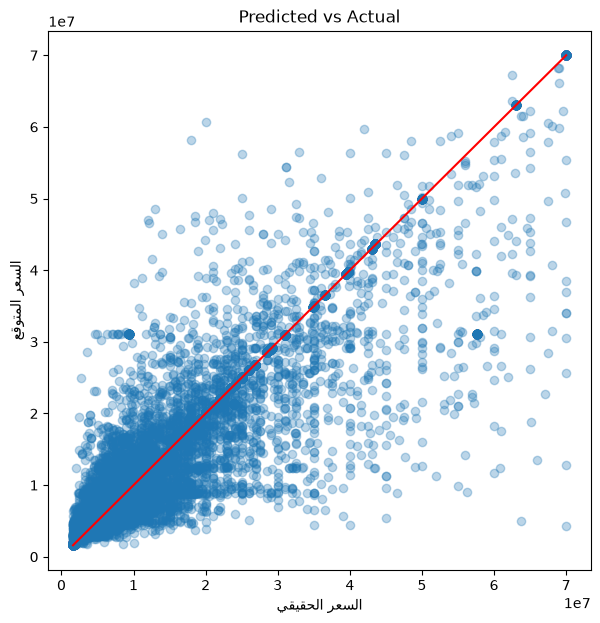

In [74]:
import matplotlib.pyplot as plt

pred_rf = model_rf.predict(X_test)
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("السعر الحقيقي")
plt.ylabel("السعر المتوقع")
plt.title("Predicted vs Actual")
plt.show()

## 2.5 Evaluate
| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 4,573,992 | 6,890,860 | 0.572 |
| Random Forest | 1,538,948 | 3,834,765 | 0.867 |

الموديل المختار: Random Forest، لأنه حقق دقة أعلى بشكل كبير (R² = 0.867 مقابل 0.572)
وخطأ أقل في كل المقاييس. هذا منطقي لأن العلاقة بين مواصفات الشقة والسعر غير خطية،
والـ Random Forest قادر على التقاط تفاعلات معقدة بين المتغيرات (مثل المنطقة وعدد الأوض)
بعكس Linear Regression الذي يفترض علاقة خطية بسيطة.

In [75]:
import joblib
import json

joblib.dump(model_rf, "house_price.pkl")

# نتأكد إنه بيشتغل بعد التحميل
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

# نحفظ قايمة المناطق عشان نستخدمها في الفرونت إند بعدين
json.dump(sorted(df["Location"].unique().tolist()), open("locations.json", "w"))

print("تم التصدير بنجاح!")

Reloaded prediction: [11314887.36294066]
تم التصدير بنجاح!
